# Phase - 4 Feature Engineering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from churn import config
from churn.features import collapse_no_internet

In [2]:
df = pd.read_parquet(config.CLEAN_DATA_FILE)
df = collapse_no_internet(df)

In [3]:
print(df.shape)                      # expect (7043, 21)
print(df["Churn"].mean().round(3))   # expect 0.265, the baseline churn rate
df[config.NO_INTERNET_COLS].apply(pd.Series.value_counts)   # only "Yes"/"No" now

(7043, 21)
0.265


,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV
No,5024,4614,4621,4999,4336
Yes,2019,2429,2422,2044,2707


#### Tenure group

In [4]:
tenure_bins = [-1, 6, 12, 24, 48, 72]
tenure_labels = ["0-6", "7-12", "13-24", "25-48", "49-72"]

df["tenure_group"] = pd.cut(df["tenure"], bins=tenure_bins, labels=tenure_labels)

Check if all values from `tenure` has been taken.

In [5]:
print(df["tenure_group"].isna().sum(), "rows without a band")   # expect 0

0 rows without a band


In [6]:
df.groupby("tenure_group", observed=True)["Churn"].agg(churn_rate="mean", 
                                                       n="size").round(3)

,churn_rate,n
tenure_group,,
0-6,0.529,1481
7-12,0.359,705
13-24,0.287,1024
25-48,0.204,1594
49-72,0.095,2239


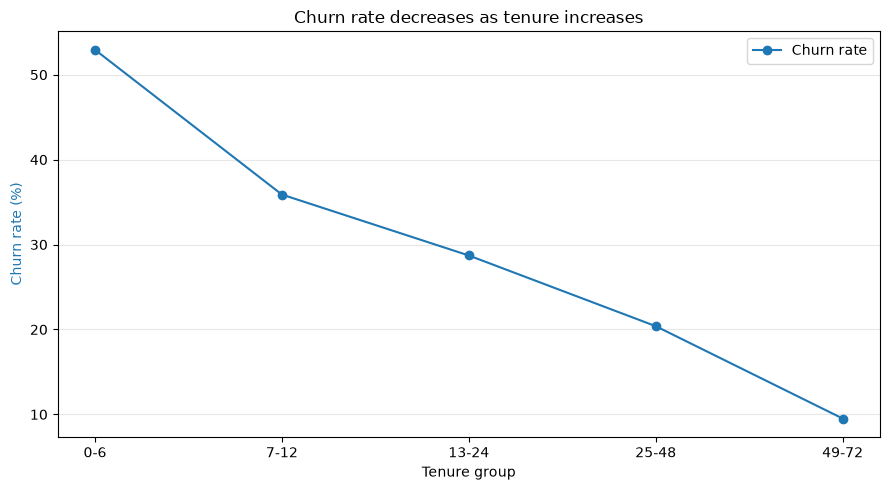

In [7]:
summary = (
    df.groupby("tenure_group", observed=True)["Churn"]
      .mean()
      .reindex(tenure_labels)
      .rename("churn_rate")
      .to_frame()
)


fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(
    tenure_labels,
    summary["churn_rate"] * 100,
    marker="o",
    color="tab:blue",
    label="Churn rate",
)


ax1.set_xlabel("Tenure group")
ax1.set_ylabel("Churn rate (%)", color="tab:blue")
ax1.set_title("Churn rate decreases as tenure increases")
ax1.grid(axis="y", alpha=0.3)

lines = ax1.get_lines() 
ax1.legend(lines, [line.get_label() for line in lines], loc="best")

plt.tight_layout()
plt.show()

Observe the churn_rate falls from band-to-band.  

The biggest drop is, because that's the interview-worthy part. Going from 0–6 to 7–12 months, churn falls 17 points (52.9% → 35.9%), the largest step between any two bands. It's the "first 6 months" kink from your EDA, and it's the reason the bands exist. 

### `num_services`
Count of add-on services (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV).

In [8]:
df["num_services"] = (df[config.NO_INTERNET_COLS] == "Yes").sum(axis=1)

In [9]:
df.groupby("num_services")["Churn"].agg(churn_rate="mean", n="size").round(3)

,churn_rate,n
num_services,,
0,0.248,2404
1,0.438,1194
2,0.319,1290
3,0.210,1114
4,0.124,700
5,0.053,341


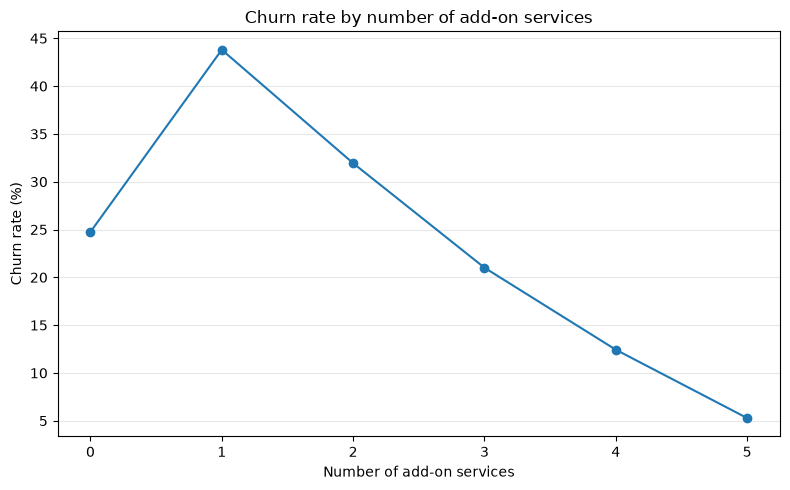

In [10]:
service_churn = (
    df.groupby("num_services")["Churn"]
      .mean()
      .mul(100)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(service_churn.index, service_churn.values, marker="o")

ax.set(
    xlabel="Number of add-on services",
    ylabel="Churn rate (%)",
    title="Churn rate by number of add-on services",
    xticks=service_churn.index,
)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### `has_family`

In [11]:
df["has_family"] = np.where((df["Partner"] == "Yes") | (df["Dependents"] == "Yes"), "Yes", "No")

In [12]:
df.groupby("has_family")["Churn"].agg(churn_rate="mean", n="size").round(3)

,churn_rate,n
has_family,,
No,0.342,3280
Yes,0.198,3763


In [13]:
df.groupby(["Partner", "Dependents"])["Churn"].agg(churn_rate="mean", n="size").round(3)

churn_rate     n
Partner Dependents                  
No      No               0.342  3280
        Yes              0.213   361
Yes     No               0.254  1653
        Yes              0.142  1749